In [2]:
import cv2
from ultralytics import YOLO
import numpy as np

In [3]:
model = YOLO("yolo11n-seg.pt")

In [8]:
image_path = "../colmap_pipeline/colmap_export/images/frame_000301.jpg"
img = cv2.imread(image_path)
h, w, _ = img.shape

In [9]:
results = model(img)


0: 640x640 1 bench, 22.2ms
Speed: 7.5ms preprocess, 22.2ms inference, 6.0ms postprocess per image at shape (1, 3, 640, 640)


In [11]:
car_mask = np.zeros((h, w), dtype=np.uint8)

for result in results:
	if result.masks is not None:
		for mask, box in zip(result.masks.xy, result.boxes):
			class_id = int(box.cls[0])
			if class_id == 2:  # Assuming class_id 2 corresponds to cars
				points = np.array(mask, dtype=np.int32)
				cv2.fillPoly(car_mask, [points], 255)

cv2.imwrite("car_mask.png", car_mask)

True

In [13]:
# Draw all masks with labels on the original image
for result in results:
	if result.masks is not None:
		for mask, box in zip(result.masks.xy, result.boxes):
			class_id = int(box.cls[0])
			label = model.names[class_id]
			points = np.array(mask, dtype=np.int32)
			cv2.polylines(img, [points], isClosed=True, color=(0, 255, 0), thickness=10)
			# Calculate the center of the bounding box for placing the label
			x1, y1, x2, y2 = map(int, box.xyxy[0])
			center_x = (x1 + x2) // 2
			center_y = (y1 + y2) // 2
			cv2.putText(img, label, (center_x, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

cv2.imwrite("segmented_image.png", img)

True

In [38]:
from ultralytics import SAM

In [39]:
model = SAM("sam2_b.pt")

In [44]:
# Define a baseline point GUARANTEED to land on the car hood
# Example: 75% down the image height, dead center horizontally
input_point = []
input_point.append([int(w * 0.5), int(h * 0.75)])
input_point.append([int(w * 0.5), int(h * 0.9)]) 
input_label = [1] * len(input_point)  # 1 means "include this object", 0 means "exclude"

# Draw the point on the image for visualization
# for point in input_point:
# 	cv2.circle(img, tuple(point), radius=100, color=(0, 0, 255), thickness=10)

# cv2.imwrite("point_on_car_hood.png", img)

In [45]:
results = model(img, points=input_point, labels=input_label)


0: 1024x1024 1 0, 1 1, 318.0ms
Speed: 15.7ms preprocess, 318.0ms inference, 16.0ms postprocess per image at shape (1, 3, 1024, 1024)


In [46]:
car_mask = np.zeros((h, w), dtype=np.uint8)
for result in results:
    if result.masks is not None:
        # SAM outputs multiple mask variations; grab the primary one
        mask_data = result.masks.data[0].cpu().numpy()
        # Convert boolean mask to binary (0 or 255)
        car_mask = (mask_data * 255).astype(np.uint8)

In [47]:
cv2.imwrite("sam_hood_mask.png", car_mask)

True

### Try suggestion from Qwen

In [58]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

In [59]:
model = YOLO("yolo11n-seg.pt")

In [60]:
image_path = "./colmap_export/images/frame_000213.jpg"
image = cv2.imread(image_path)


0: 640x640 1 kite, 43.3ms
Speed: 9.5ms preprocess, 43.3ms inference, 14.4ms postprocess per image at shape (1, 3, 640, 640)


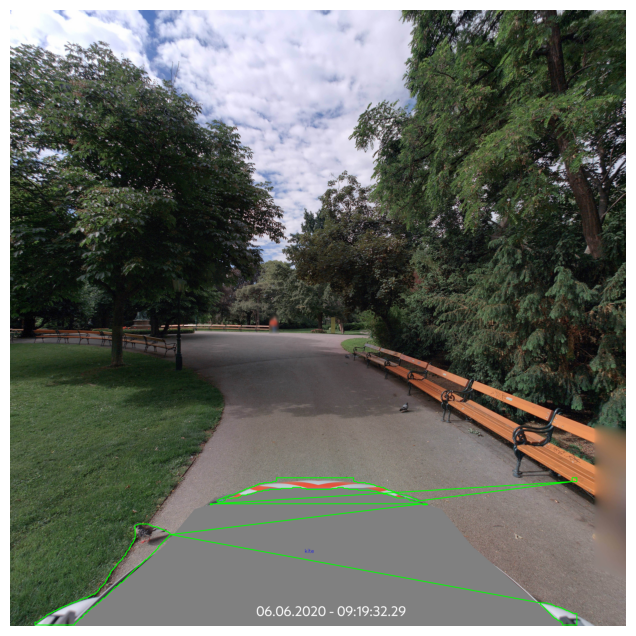

In [61]:
# 2. Detect objects in the image
# Reload clean image each execution to avoid stacked overlays
image = cv2.imread(image_path)
if image is None:
	raise FileNotFoundError(f"Could not read image: {image_path}")

results = model(image)

# Draw on a separate visualization buffer
vis_image = image.copy()

for result in results:
	if result.masks is None:
		continue

	for mask, box in zip(result.masks.xy, result.boxes):
		class_id = int(box.cls[0])
		label = model.names[class_id]

		points = np.array(mask, dtype=np.int32).reshape((-1, 1, 2))
		cv2.polylines(vis_image, [points], isClosed=True, color=(0, 255, 0), thickness=10)

		x1, y1, x2, y2 = map(int, box.xyxy[0])
		center_x = (x1 + x2) // 2
		center_y = (y1 + y2) // 2
		cv2.putText(
			vis_image,
			label,
			(center_x, center_y),
			cv2.FONT_HERSHEY_SIMPLEX,
			2.0,
			(255, 0, 0),
			2,
			cv2.LINE_AA
		)

plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.gcf().set_size_inches(8, 8)

In [43]:
# 3. Analyze detections near the bottom of the image
# Let's assume the original mask ends at Y-coordinate 60% of height (adjust based on your mask)
h, w, _ = image.shape

In [44]:
# 4. Analyze Detections near the bottom
leak_line_y = -1

# We scan only the bottom 25% of the image where leakage usually happens
for box in results[0].boxes:
	x1, y1, x2, y2 = map(int, box.xyxy[0])
	
	# Check if this object is near the bottom edge (the leak zone)
	if y2 > (h * 0.7):
		# We want the lowest point in the image (highest Y coordinate)
		if y2 > leak_line_y:
			leak_line_y = y2

In [45]:
# 5. Generate New Mask Polygon
new_mask_points = []

if leak_line_y != -1:
	# Define a buffer area below the leak to ensure we cover everything safely
	# We assume the mask needs to cover the bottom-most detected object fully
	safe_boundary = int(leak_line_y) + (h * 0.05) 
	
	# Create a polygon that effectively covers the bottom of the image
	# starting from this safe boundary down to the edges.
	
	# Points for the new mask: 
	# - Bottom Left Corner
	# - Bottom Right Corner
	# - The "Leak" line at the top of the mask
	
	mask_points = [
		(0, h),                    # Bottom Left
		(w, h),                   # Bottom Right
		(0, safe_boundary),       # Top Left of Mask (The leak edge)
		(w, safe_boundary)        # Top Right of Mask (The leak edge)
	]
	
	new_mask_points = mask_points
	
else:
	print("No leaks detected below the threshold.")

In [57]:
new_mask_points

[(0, 7130), (7130, 7130), (0, 7304.5), (7130, 7304.5)]

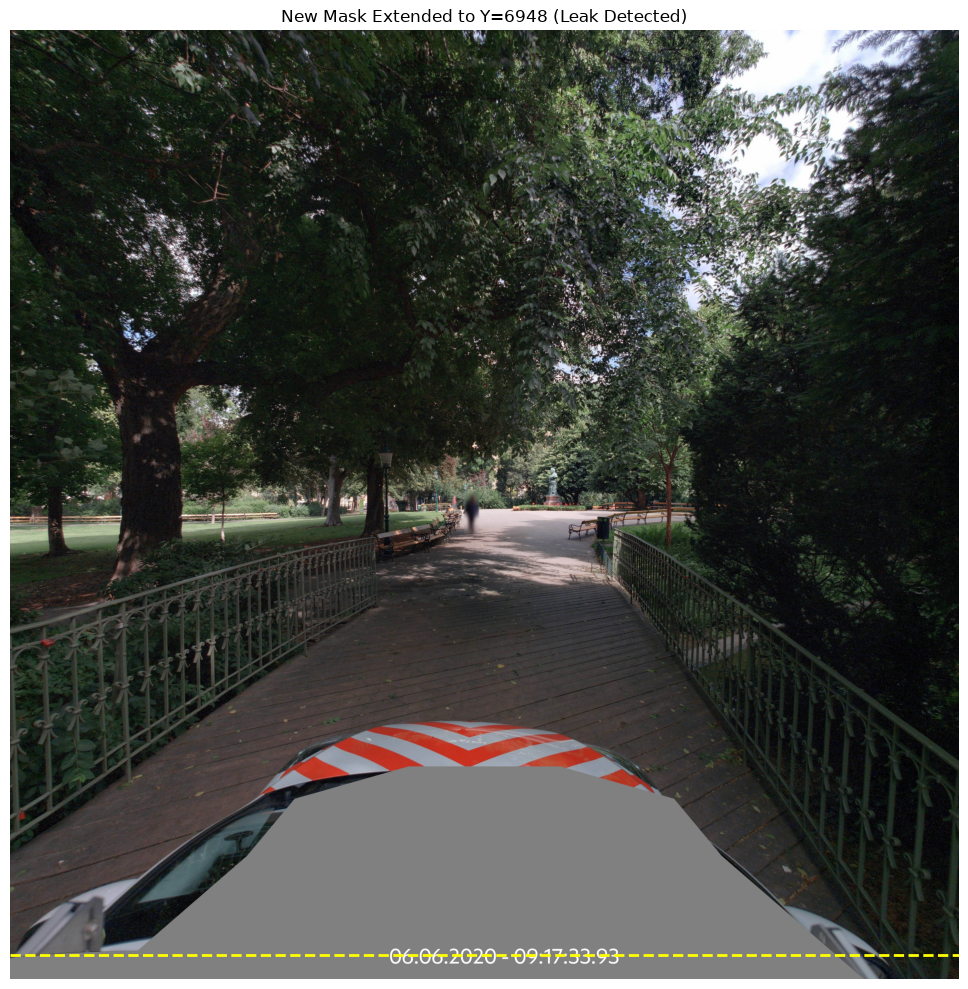

In [56]:
# 6. Draw and Visualize the New Mask
new_mask = np.zeros((h, w), dtype=np.uint8)

# Convert list to numpy array for cv2.fillPoly
try:
	cv2.fillPoly(new_mask, [np.array(new_mask_points, dtype=np.int32)], 255)
except Exception as e:
	print(f"Error filling polygon: {e}")

overlay_image = image.copy()
# Color the mask area Red for visualization
if len(new_mask_points) > 0:
	overlay_image[new_mask == 255] = (255, 0, 0) 
else:
	# If no leak found, draw nothing (or draw original gray mask if you had it)
	print("No mask applied.")

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(overlay_image, cv2.COLOR_BGR2RGB))

# Add text showing where the detection happened
if leak_line_y != -1:
	plt.title(f"New Mask Extended to Y={leak_line_y} (Leak Detected)")
	# Draw a horizontal line at the leak detection point for clarity
	plt.axhline(y=leak_line_y, color='yellow', linestyle='--', linewidth=2, label='Leak Detection Line')
else:
	plt.title("No Leak Detected")
	
plt.axis("off")
plt.tight_layout()
plt.show()

### Train YOLO11 with manually annotated masks to detect the car hood and the gray mask

In [1]:
import cv2
from ultralytics import YOLO
import numpy as np
import os

In [2]:
# Import the base model
model = YOLO("yolo11n-seg.pt")

images_path = "../LiDAR_kappazunder_stadtpark/Los_6A/Bild-Rohdaten/Trajektorie_15767/Sensor_110021/"
masks_path = images_path + "masks/"

# Get all images in the directory
image_files = [f for f in os.listdir(images_path) if f.endswith('.jpg')]
mask_files = [f for f in os.listdir(masks_path) if f.endswith('.jpg')]

In [17]:
image_files

['WE1H2XH4.jpg',
 'WE1H2XH5.jpg',
 'WE1H2XH6.jpg',
 'WE1H2XH7.jpg',
 'WE1H2XH8.jpg',
 'WE1H2XH9.jpg',
 'WE1H2XHA.jpg',
 'WE1H2XHB.jpg',
 'WE1H2XHC.jpg',
 'WE1H2XHD.jpg',
 'WE1H2XHE.jpg',
 'WE1H2XHF.jpg',
 'WE1H2XHG.jpg',
 'WE1H2XHH.jpg',
 'WE1H2XHI.jpg',
 'WE1H2XHJ.jpg',
 'WE1H2XHK.jpg',
 'WE1H2XHL.jpg',
 'WE1H2XHM.jpg',
 'WE1H2XHN.jpg',
 'WE1H2XHO.jpg',
 'WE1H2XHP.jpg',
 'WE1H2XHQ.jpg',
 'WE1H2XHS.jpg',
 'WE1H2XHU.jpg',
 'WE1H2XHV.jpg',
 'WE1H2XHW.jpg',
 'WE1H2XHX.jpg',
 'WE1H2XHY.jpg',
 'WE1H2XHZ.jpg',
 'WE1H2XI0.jpg',
 'WE1H2XI1.jpg',
 'WE1H2XI2.jpg',
 'WE1H2XI3.jpg',
 'WE1H2XI4.jpg',
 'WE1H2XI5.jpg',
 'WE1H2XI6.jpg',
 'WE1H2XI7.jpg',
 'WE1H2XI9.jpg',
 'WE1H2XIA.jpg',
 'WE1H2XIB.jpg',
 'WE1H2XIC.jpg',
 'WE1H2XID.jpg',
 'WE1H2XIE.jpg',
 'WE1H2XIG.jpg',
 'WE1H2XIH.jpg',
 'WE1H2XII.jpg',
 'WE1H2XIJ.jpg',
 'WE1H2XIK.jpg',
 'WE1H2XIL.jpg',
 'WE1H2XMA.jpg',
 'WE1H2XMB.jpg',
 'WE1H2XMC.jpg',
 'WE1H2XMD.jpg',
 'WE1H2XME.jpg',
 'WE1H2XMF.jpg',
 'WE1H2XMG.jpg',
 'WE1H2XMH.jpg',
 'WE1H2XMI.jpg

In [18]:
image = cv2.imread(images_path + image_files[207])
results = model(image)


0: 640x640 (no detections), 88.5ms
Speed: 5.9ms preprocess, 88.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


In [19]:
mask_files

['frame.jpg',
 'frame_00000.jpg',
 'frame_00001.jpg',
 'frame_00002.jpg',
 'frame_00003.jpg',
 'frame_00004.jpg',
 'frame_00005.jpg',
 'frame_00006.jpg',
 'frame_00007.jpg',
 'frame_00008.jpg',
 'frame_00009.jpg',
 'frame_00010.jpg',
 'frame_00011.jpg',
 'frame_00012.jpg',
 'frame_00013.jpg',
 'frame_00014.jpg',
 'frame_00015.jpg',
 'frame_00016.jpg',
 'frame_00017.jpg',
 'frame_00018.jpg',
 'frame_00019.jpg',
 'frame_00020.jpg',
 'frame_00021.jpg',
 'frame_00022.jpg',
 'frame_00023.jpg',
 'frame_00024.jpg',
 'frame_00025.jpg',
 'frame_00026.jpg',
 'frame_00027.jpg',
 'frame_00028.jpg',
 'frame_00029.jpg',
 'frame_00030.jpg',
 'frame_00031.jpg',
 'frame_00032.jpg',
 'frame_00033.jpg',
 'frame_00034.jpg',
 'frame_00035.jpg',
 'frame_00036.jpg',
 'frame_00037.jpg',
 'frame_00038.jpg',
 'frame_00039.jpg',
 'frame_00040.jpg',
 'frame_00041.jpg',
 'frame_00042.jpg',
 'frame_00043.jpg',
 'frame_00044.jpg',
 'frame_00045.jpg',
 'frame_00046.jpg',
 'frame_00047.jpg',
 'frame_00048.jpg',
 'fram

In [2]:
from prepare_yolo_database import draw_sanity_check, OUTPUT_ROOT

In [35]:
# Execute the python script prepare_yolo_dataset.py
!python prepare_yolo_database.py

[WARN] Mismatch: 228 images vs 229 masks. Truncating to the shorter list -- check this is correct!
First few matched pairs (sanity check):
       WE1H2XH4.jpg  <->  frame.jpg
       WE1H2XH5.jpg  <->  frame_00000.jpg
       WE1H2XH6.jpg  <->  frame_00001.jpg
       ... 228 pairs total

Found 228 pairs -> 193 train / 35 val

Done. Dataset written to: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_finetune_images
data.yaml:
path: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_finetune_images
train: images/train
val: images/val

names:
  0: object

Sanity check image ('train/WE1H2XMS.jpg') written to: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_finetune_images\sanity_check.jpg


In [22]:
draw_sanity_check(OUTPUT_ROOT)

Sanity check image ('train/WE1H2XHK.jpg') written to: f:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_finetune_images\sanity_check.jpg


In [23]:
model.train(data="yolo_finetune_images/data.yaml", epochs=50, imgsz=640, freeze=10, batch=2) # freeze backbone

New https://pypi.org/project/ultralytics/8.4.94 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.78  Python-3.12.13 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4070, 12281MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_finetune_images/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001E770618C50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [30]:
model.save("yolo26n-seg_finetuned.pt")

In [3]:
model = YOLO("yolo26n-seg_finetuned.pt")

In [7]:
image = cv2.imread("yolo_finetune_images/images/val/WE1H2XMH.jpg")
results = model(image, imgsz=640)


0: 640x640 1 object, 38.9ms
Speed: 7.1ms preprocess, 38.9ms inference, 9.4ms postprocess per image at shape (1, 3, 640, 640)


In [5]:
# Plot the results
import matplotlib.pyplot as plt

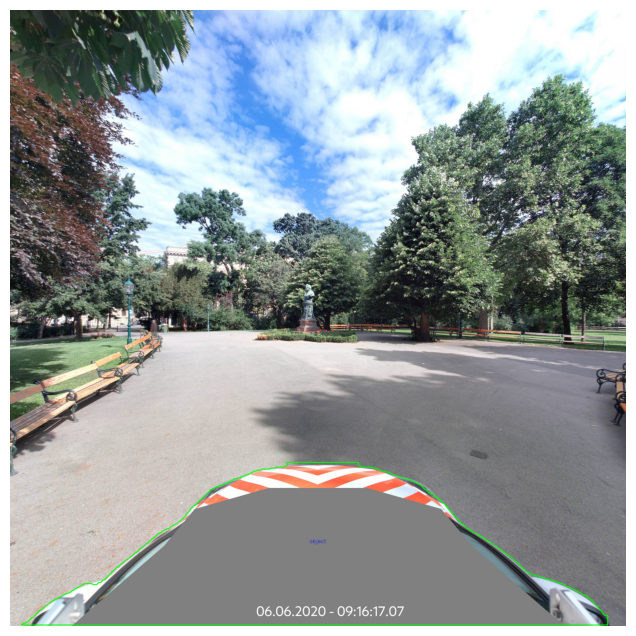

In [8]:
vis_image = image.copy()

for result in results:
	if result.masks is None:
		continue

	for mask, box in zip(result.masks.xy, result.boxes):
		class_id = int(box.cls[0])
		label = model.names[class_id]

		points = np.array(mask, dtype=np.int32).reshape((-1, 1, 2))
		cv2.polylines(vis_image, [points], isClosed=True, color=(0, 255, 0), thickness=10)

		x1, y1, x2, y2 = map(int, box.xyxy[0])
		center_x = (x1 + x2) // 2
		center_y = (y1 + y2) // 2
		cv2.putText(
			vis_image,
			label,
			(center_x, center_y),
			cv2.FONT_HERSHEY_SIMPLEX,
			2.0,
			(255, 0, 0),
			2,
			cv2.LINE_AA
		)

plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.gcf().set_size_inches(8, 8)
plt.show()

In [31]:
!yolo detect val model=yolo26n-seg_finetuned.pt data=yolo_finetune_images/data.yaml

WARNING conflicting 'task=detect' passed with 'task=segment' model. Ignoring 'task=detect' and updating to 'task=segment' to match model.
Ultralytics 8.4.78  Python-3.12.13 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4070, 12281MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients
val: Fast image access  (ping: 0.10.1 ms, read: 1834.3159.1 MB/s, size: 4724.7 KB)

val: Scanning F:\Documents\LiDAR_kappazunder_stadpark_reduced\yolo_finetune_images\labels\val.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35  0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 33% ━━━━──────── 1/3 23.8s/it 7.1s<47.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 66% ━━━━━━━━──── 2/3 4.2s/it 8.6s<4.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     M